Generating synthetic biosignal data for analysis (length: 30 sec)...
Synthetic data generated and saved to 'E:/dataset/Hypertension/GURO/018651610328.csv'.
Loading data from 'E:/dataset/Hypertension/GURO/018651610328.csv'...
Uniform time intervals detected. Skipping resampling.
Bandpass filtering completed.
Detected 13 R-peaks.
RR interval (HRV) computation completed.
Saved result plot as 'hrv_analysis_result.png'.


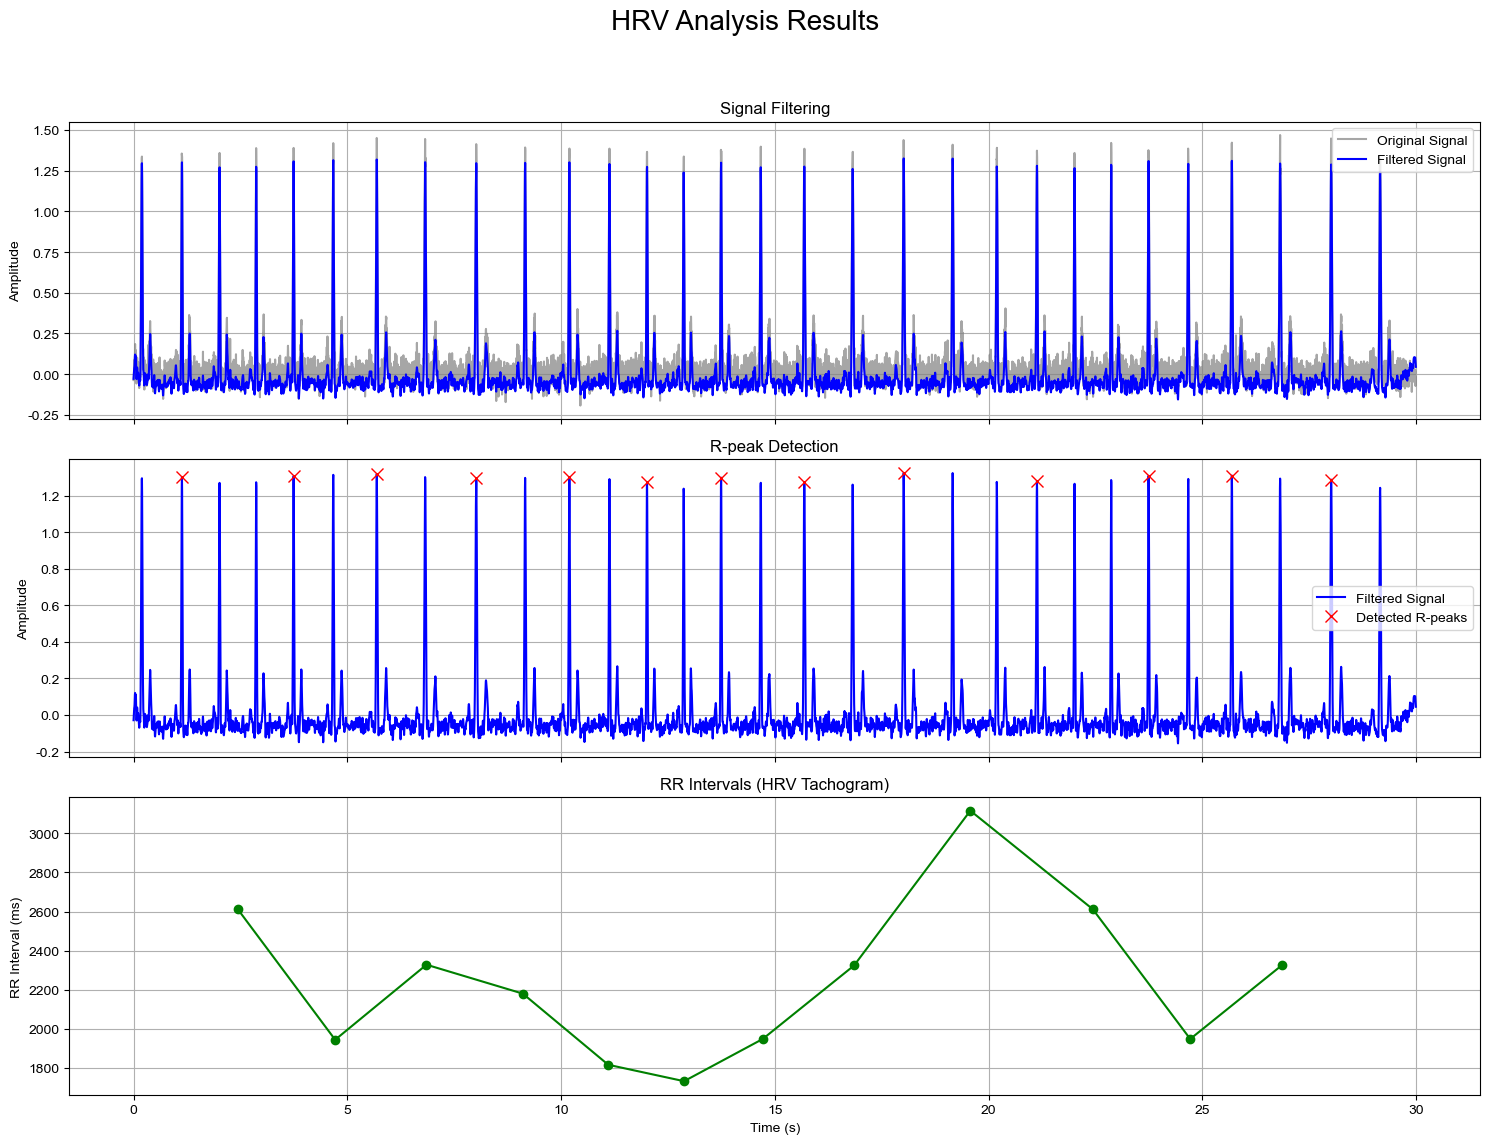

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
from scipy.interpolate import interp1d

def generate_synthetic_data(file_path, duration_sec=30, fs=250):
    """
    Generate synthetic ECG-like biosignal data for analysis and save as a CSV file.
    """
    print(f"Generating synthetic biosignal data for analysis (length: {duration_sec} sec)...")
    t = np.linspace(0, duration_sec, int(duration_sec * fs), endpoint=False)
    
    # Vary heart rate (60–80 bpm) dynamically over time
    hr_dynamic = 60 + 10 * np.sin(2 * np.pi * 0.1 * t)
    
    # Simplified ECG P, Q, R, S, T waves
    beat_period = 60 / hr_dynamic
    phase = np.cumsum(1 / fs / beat_period)
    phase_mod = np.mod(phase, 1.0)
    
    # R-peak, T-wave, P-wave, Q/S dips
    signal = 1.5 * np.exp(-2000 * (phase_mod - 0.2)**2)
    signal += 0.3 * np.exp(-1500 * (phase_mod - 0.4)**2)
    signal += 0.1 * np.exp(-1000 * (phase_mod - 0.05)**2)
    signal -= 0.2 * np.exp(-3000 * (phase_mod - 0.18)**2)
    signal -= 0.2 * np.exp(-3000 * (phase_mod - 0.22)**2)
    
    # Add noise
    noise = np.random.normal(0, 0.05, len(t))
    signal += noise
    
    # Save as CSV
    df = pd.DataFrame({'time': t, 'signal': signal})
    df.to_csv(file_path, sep=' ', header=False, index=False, float_format='%.4f')
    print(f"Synthetic data generated and saved to '{file_path}'.")


def analyze_hrv_from_csv(file_path, column_names=['time', 'signal']):
    """
    Load signal from CSV, apply filtering, detect R-peaks, compute HRV (RR intervals),
    and visualize results.
    """
    print(f"Loading data from '{file_path}'...")
    try:
        df = pd.read_csv(file_path, sep='\\s+', header=None, names=column_names, engine='python')
    except Exception as e:
        print(f"Error: Failed to read CSV file. ({e})")
        return
        
    time = df[column_names[0]].to_numpy()
    signal = df[column_names[1]].to_numpy()

    # [Important] Resampling if time intervals are not uniform
    fs = 250
    time_diffs = np.diff(time)
    is_uniform = np.all(np.isclose(time_diffs, 1/fs))

    if not is_uniform:
        print("Non-uniform time intervals detected. Resampling...")
        time_uniform = np.arange(time[0], time[-1], 1/fs)
        interp_func = interp1d(time, signal, kind='linear', fill_value="extrapolate")
        signal_uniform = interp_func(time_uniform)
    else:
        print("Uniform time intervals detected. Skipping resampling.")
        time_uniform = time
        signal_uniform = signal

    # Bandpass filtering
    lowcut, highcut, order = 0.5, 40.0, 2
    nyquist = 0.5 * fs
    b, a = butter(order, [lowcut/nyquist, highcut/nyquist], btype='band')
    signal_filtered = filtfilt(b, a, signal_uniform)
    print("Bandpass filtering completed.")

    # R-peak detection
    min_hr_bpm = 40.0
    min_distance_samples = fs * (60.0 / min_hr_bpm)
    peaks, _ = find_peaks(signal_filtered, height=0.5, distance=min_distance_samples)
    print(f"Detected {len(peaks)} R-peaks.")

    if len(peaks) < 2:
        print("Not enough R-peaks detected to compute HRV.")
        return

    # HRV (RR interval) computation
    peak_times = time_uniform[peaks]
    rr_intervals = np.diff(peak_times) * 1000
    rr_interval_times = peak_times[:-1] + rr_intervals / 2000
    print("RR interval (HRV) computation completed.")

    # Visualization
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['axes.unicode_minus'] = False
    fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
    fig.suptitle('HRV Analysis Results', fontsize=20)

    axes[0].plot(time_uniform, signal_uniform, label='Original Signal', color='gray', alpha=0.7)
    axes[0].plot(time_uniform, signal_filtered, label='Filtered Signal', color='blue')
    axes[0].set_title('Signal Filtering'); axes[0].set_ylabel('Amplitude'); axes[0].legend(); axes[0].grid(True)

    axes[1].plot(time_uniform, signal_filtered, label='Filtered Signal', color='blue')
    axes[1].plot(time_uniform[peaks], signal_filtered[peaks], 'x', color='red', markersize=8, label='Detected R-peaks')
    axes[1].set_title('R-peak Detection'); axes[1].set_ylabel('Amplitude'); axes[1].legend(); axes[1].grid(True)

    axes[2].plot(rr_interval_times, rr_intervals, marker='o', linestyle='-', color='green')
    axes[2].set_title('RR Intervals (HRV Tachogram)'); axes[2].set_xlabel('Time (s)'); axes[2].set_ylabel('RR Interval (ms)'); axes[2].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("hrv_analysis_result.png")
    print("Saved result plot as 'hrv_analysis_result.png'.")
    plt.show()

# --- Run code ---
# 1. Generate example CSV file
file_to_analyze = 'E:/dataset/Hypertension/GURO/018651610328.csv'
generate_synthetic_data(file_to_analyze)

# 2. Run HRV analysis
analyze_hrv_from_csv(file_to_analyze)

# ※ For real data, uncomment below and set file path
# analyze_hrv_from_csv('C:/your_path/your_real_data.csv')
